# **Load Data**

In [3]:
import sqlite3
import pandas as pd

# Create a Database
conn = sqlite3.connect('walmart_analytics.db')
cursor = conn.cursor()
print("Database created and Successfully Connected to SQLite")

# Data Ingestion
sales_df_raw = pd.read_csv('Walmart_Sales.csv')
sales_df_raw.to_sql('sales_table', conn, if_exists='replace', index=False)
print("Sales Table is Ready")

# Data Verification with SQL
query_verif = "SELECT * FROM sales_table LIMIT 5;"
sales_df_check = pd.read_sql_query(query_verif, conn)

conn.close()
sales_df_check

Database created and Successfully Connected to SQLite
Sales Table is Ready


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# **Data Quality Check with SQL**

In [4]:
# Check Missing Values
import sqlite3
import pandas as pd
conn = sqlite3.connect('walmart_analytics.db')

query_check_null = """
SELECT
  SUM(CASE WHEN Store IS NULL THEN 1 ELSE 0 END) AS null_store,
  SUM(CASE WHEN Date IS NULL THEN 1 ELSE 0 END) AS null_date,
  SUM(CASE WHEN Weekly_Sales IS NULL THEN 1 ELSE 0 END) AS null_weekly_sales,
  SUM(CASE WHEN Holiday_Flag IS NULL THEN 1 ELSE 0 END) AS null_holiday,
  SUM(CASE WHEN Temperature IS NULL THEN 1 ELSE 0 END) AS null_temperature,
  SUM(CASE WHEN Fuel_Price IS NULL THEN 1 ELSE 0 END) AS null_fuel_price,
  SUM(CASE WHEN CPI IS NULL THEN 1 ELSE 0 END) AS null_cpi,
  SUM(CASE WHEN Unemployment IS NULL THEN 1 ELSE 0 END) AS null_unemployment
FROM sales_table;
"""
print("CHECKING FOR MISSING VALUES:")
df_null = pd.read_sql_query(query_check_null, conn)
display(df_null)

CHECKING FOR MISSING VALUES:


,null_store,null_date,null_weekly_sales,null_holiday,null_temperature,null_fuel_price,null_cpi,null_unemployment
0,0,0,0,0,0,0,0,0


In [5]:
# Checking for and handling duplicate data
query_check_dup = """
SELECT
  Store, Date, COUNT(*) AS occurrence_count
  FROM sales_table
  GROUP BY Store, Date
  HAVING occurrence_count > 1;
"""
print("CHECKING FOR DUPLICATE DATA:")
df_dup = pd.read_sql_query(query_check_dup, conn)

if df_dup.empty:
  print("No duplicate data found.")
else:
  print("Duplicate data found:")
  display(df_dup)

CHECKING FOR DUPLICATE DATA:
No duplicate data found.


In [6]:
# Check for Anomaly Values (Example: Negative sales)
query_check_anomaly = """
SELECT
  COUNT(*) AS anomaly_count
FROM sales_table
WHERE Weekly_Sales <= 0;
"""
print("CHECKING FOR ANOMALY VALUES:")
df_anomaly = pd.read_sql_query(query_check_anomaly, conn)
display(df_anomaly)

CHECKING FOR ANOMALY VALUES:


,anomaly_count
0,0


# **Data Type Conversion**

In [7]:
conn = sqlite3.connect('walmart_analytics.db')

query_fetch_all = "SELECT * FROM sales_table;"
sales_df = pd.read_sql_query(query_fetch_all, conn)
conn.close()

# Check original data type before conversion
print("Data types Before Transformation:")
print(sales_df.dtypes)
print("\n" + "-"*40 + "\n")

# Date Format Correction
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d-%m-%Y')
print("Date types After Transformation:")
print(sales_df.dtypes)
print("\n" + "-"*40 + "\n")

print("First 5 rows of transformed dataset:")
display(sales_df.head())

Data types Before Transformation:
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

----------------------------------------

Date types After Transformation:
Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

----------------------------------------

First 5 rows of transformed dataset:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


# **Exploratory Data Analysis (EDA) - Visualizing Insights**

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

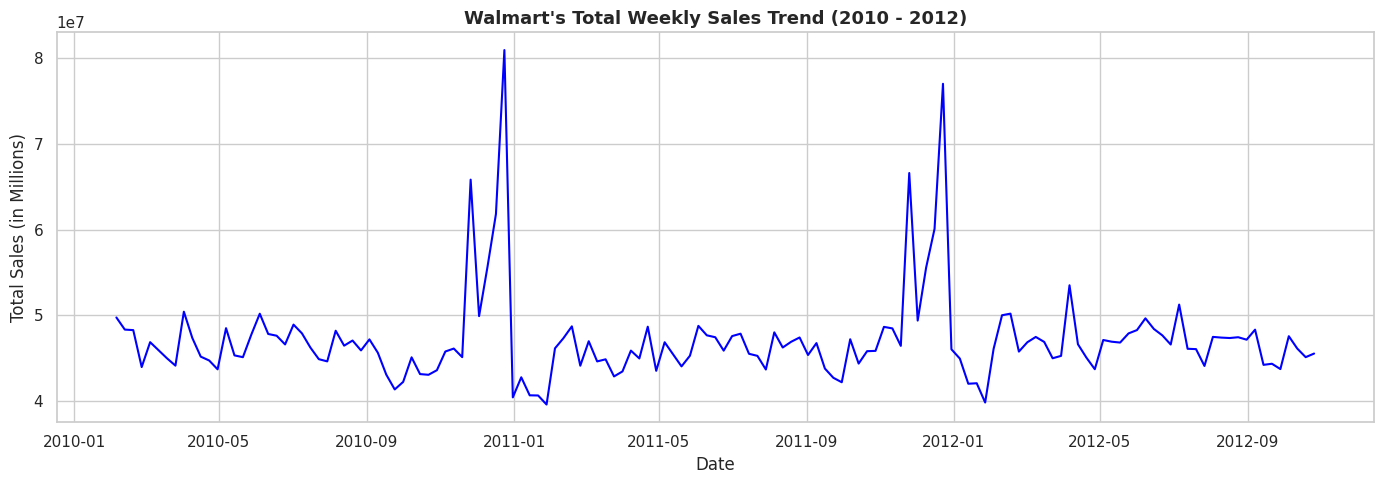

In [9]:
# Walmart's Total Weekly Sales Trend
timeline_sales = sales_df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(14, 5))
sns.lineplot(data=timeline_sales, x='Date', y='Weekly_Sales', color='blue')

plt.title("Walmart's Total Weekly Sales Trend (2010 - 2012)", fontsize=13, fontweight='bold')
plt.xlabel("Date",fontsize=12)
plt.ylabel("Total Sales (in Millions)", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5158/1396363820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=sales_df, x='Holiday_Flag', y='Weekly_Sales', palette='Set2')
/tmp/ipykernel_5158/1396363820.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Regular Week (0)', 'Holiday Week (1)'])


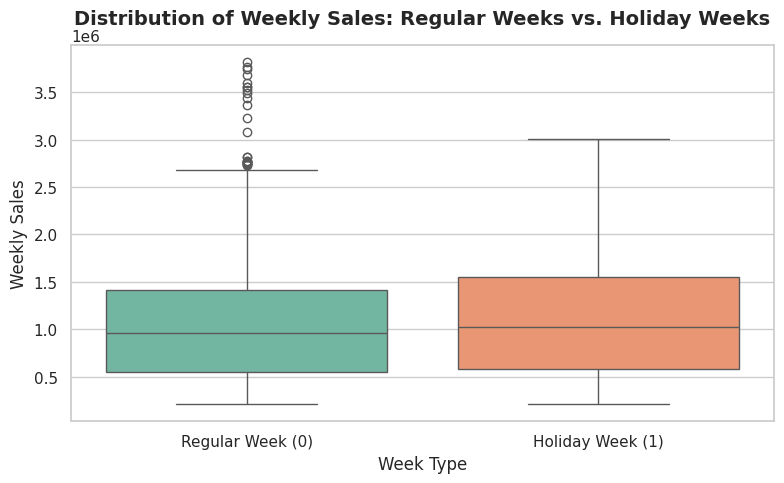

In [10]:
# Impact of Holidays on Sales
plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=sales_df, x='Holiday_Flag', y='Weekly_Sales', palette='Set2')

ax.set_xticklabels(['Regular Week (0)', 'Holiday Week (1)'])

plt.title("Distribution of Weekly Sales: Regular Weeks vs. Holiday Weeks", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Weekly Sales", fontsize=12)
plt.tight_layout()
plt.show()

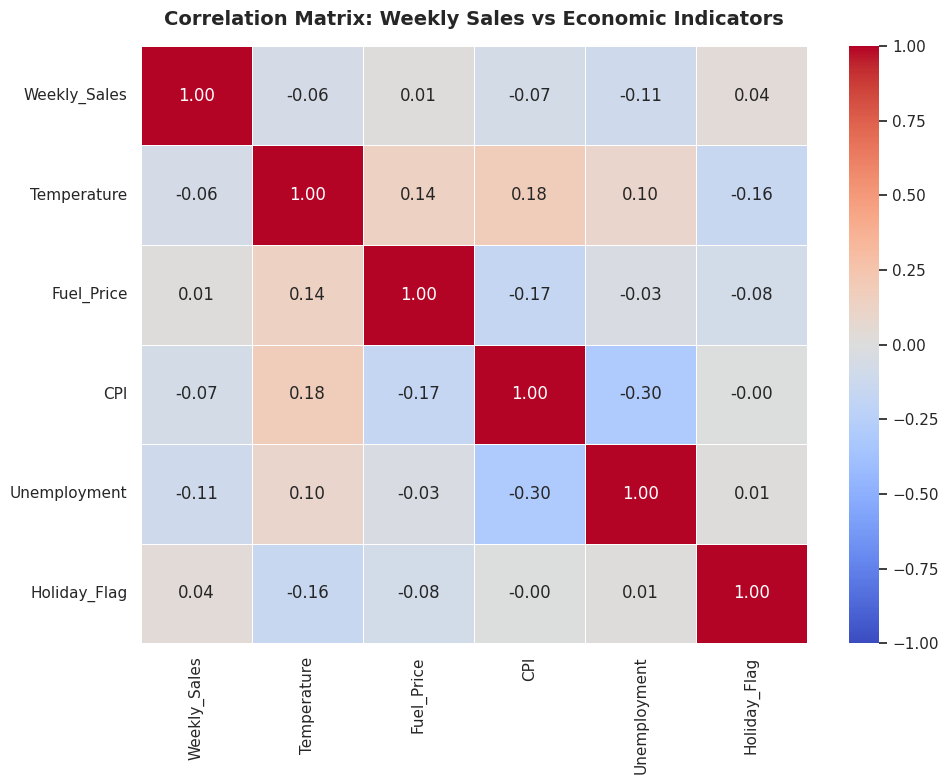

In [11]:
# Correlation Matrix: Weekly Sales vs Economic Indicators
import numpy as np

numerical_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']
corr_matrix = sales_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths='0.5', vmin=-1, vmax=1)

plt.title("Correlation Matrix: Weekly Sales vs Economic Indicators", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# **Feature Engineering**

In [12]:
sales_df['Year'] = sales_df['Date'].dt.year
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['WeekOfYear'] = sales_df['Date'].dt.isocalendar().week.astype(int)

print("Features extracted successfully!")
print(f"Current columns in dataset: {list(sales_df.columns)}")
print("\nSample of the new features:")
display(sales_df[['Date', 'Year', 'Month', 'WeekOfYear']].head())

Features extracted successfully!
Current columns in dataset: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear']

Sample of the new features:


,Date,Year,Month,WeekOfYear
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


# **Data Splitting (Time-Based Split)**

In [13]:
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear']

X = sales_df[features]
y = sales_df['Weekly_Sales']

train_mask = sales_df['Year'] < 2012
test_mask = sales_df['Year'] == 2012

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Total Rows in Dataset : {len(sales_df)}")
print(f"Training Set Size (2010-2011) : {X_train.shape[0]} rows ({round(X_train.shape[0]/len(sales_df)*100, 2)}%)")
print(f"Testing Set Size (2012) : {X_test.shape[0]} rows ({round(X_test.shape[0]/len(sales_df)*100, 2)}%)")

Total Rows in Dataset : 6435
Training Set Size (2010-2011) : 4500 rows (69.93%)
Testing Set Size (2012) : 1935 rows (30.07%)


# **Model Training & Evaluation**

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest Regressor...")
rf_model.fit(X_train, y_train)
print("Model Training Completed Successfully!")

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE EVALUATION (YEAR 2012) ---")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"R-squared (R2) Score     : {r2:.4f} ({round(r2*100, 2)}%)")

Training Random Forest Regressor...
Model Training Completed Successfully!

--- MODEL PERFORMANCE EVALUATION (YEAR 2012) ---
Mean Absolute Error (MAE): 157,309.96
R-squared (R2) Score     : 0.7237 (72.37%)


/tmp/ipykernel_5158/3906728859.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


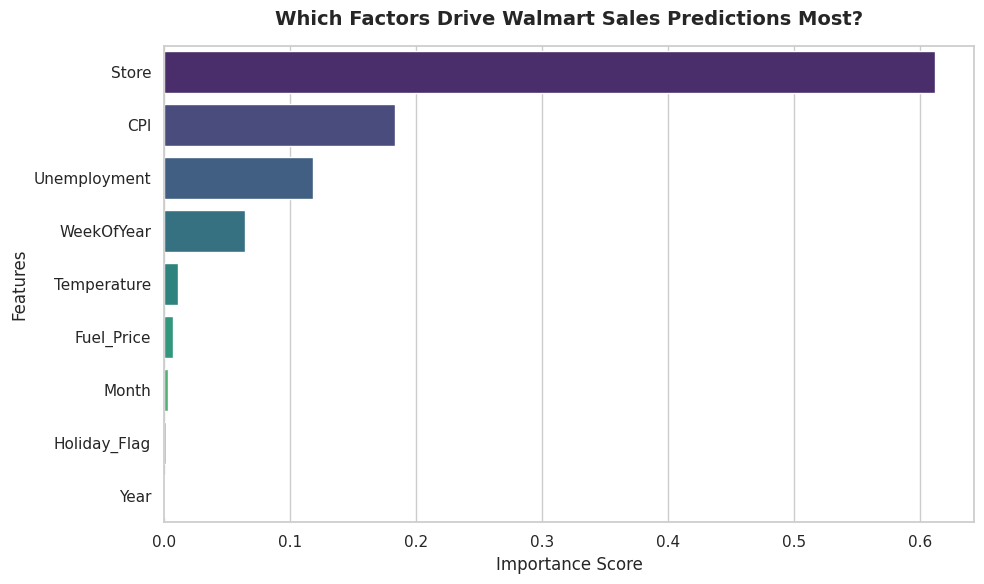

Feature Importance Ranking:


,Feature,Importance
0,Store,0.612171
4,CPI,0.183487
5,Unemployment,0.118254
8,WeekOfYear,0.064008
2,Temperature,0.010546
3,Fuel_Price,0.007105
7,Month,0.002515
1,Holiday_Flag,0.001627
6,Year,0.000286


In [15]:
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')

plt.title("Which Factors Drive Walmart Sales Predictions Most?", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
display(feature_imp_df)